# LH Nautical — Etapa 4: Análise de Clientes

**Descoberta central:** todos os 49 clientes operam no vermelho com câmbio real PTAX/BCB —
margem geral de **-5,3%** (R$ -139M). O problema não é a base de clientes; é o preço de venda defasado.

**Ferramenta:** Spark SQL (mesmo padrão da Etapa 3).

| Seção | Conteúdo |
|---|---|
| 1 | Visão geral — cobertura, frequência, receita média |
| 2 | Receita acumulada por cliente — ranking e concentração |
| 3 | Segmentação RFM simplificada (Recência, Frequência, Valor) |
| 4 | Distribuição geográfica por estado |
| 5 | Vendas médias por dia da semana (com zeros incluídos) |
| 6 | Rentabilidade por cliente — lucro e margem real com câmbio PTAX/BCB |
| 7 | RFM × Margem — cruzamento segmento de lealdade vs rentabilidade real |
| 8 | Resumo executivo |

**Premissas:**
- Custo vigente: `usd_price` mais recente com `start_date ≤ sale_date` (subquery correlacionada)
- Câmbio: PTAX de fechamento do dia da venda — silver_cambio (Delta Lake) gerado pela Etapa 2
- `total` nas vendas = receita bruta em BRL

## 0. Setup

### Como Executar Este Notebook
1. Execute as células em ordem, do topo ao fim.
2. Este notebook lê as tabelas `gold_fct_vendas` e `silver_clientes` do Delta Lake.
3. Todas as métricas de margem já consideram câmbio PTAX/BCB embutido na Camada Ouro.
4. Ao final, rode a célula de checks para validar consistência dos principais resultados.

In [0]:

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns

# ── Compatibilidade: Databricks Runtime (UI) vs databricks-connect (VS Code) ─
try:
    spark  # já definido no Databricks runtime
    dbutils.widgets.text("catalog", "workspace",   "Catalog")
    dbutils.widgets.text("schema",  "lh_nautical", "Schema")
    CATALOG = dbutils.widgets.get("catalog")
    SCHEMA  = dbutils.widgets.get("schema")
except NameError:
    from databricks.connect import DatabricksSession
    spark   = DatabricksSession.builder.serverless().getOrCreate()
    CATALOG = "workspace"
    SCHEMA  = "lh_nautical"

vendas_gold = spark.table(f"{CATALOG}.{SCHEMA}.gold_fct_vendas").toPandas()
vendas_gold["sale_date"] = pd.to_datetime(vendas_gold["sale_date"])

clientes = spark.table(f"{CATALOG}.{SCHEMA}.silver_clientes").toPandas()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.family"]    = "DejaVu Sans"

print(f"vendas_gold: {len(vendas_gold):,} linhas | clientes: {len(clientes)}")
print("Setup concluido.")

vendas_gold: 9,895 linhas | clientes: 49
Setup concluido.


In [0]:
# ── Catálogo Delta Lake disponível ──────────────────────────────────────────
spark.sql("SHOW TABLES IN workspace.lh_nautical").show(truncate=False)

+-----------+--------------------+-----------+
|database   |tableName           |isTemporary|
+-----------+--------------------+-----------+
|lh_nautical|bronze_clientes     |false      |
|lh_nautical|bronze_custos       |false      |
|lh_nautical|bronze_produtos     |false      |
|lh_nautical|bronze_vendas       |false      |
|lh_nautical|gold_fct_vendas     |false      |
|lh_nautical|silver_cambio       |false      |
|lh_nautical|silver_clientes     |false      |
|lh_nautical|silver_custos       |false      |
|lh_nautical|silver_produtos     |false      |
|lh_nautical|silver_vendas       |false      |
|lh_nautical|vwp_kpis_cliente    |false      |
|lh_nautical|vwp_kpis_mensal     |false      |
|lh_nautical|vwp_kpis_produto    |false      |
|lh_nautical|vwp_resumo_executivo|false      |
+-----------+--------------------+-----------+



## 1. Visão Geral dos Clientes

In [0]:
# Resumo geral: quantos clientes, quantos compraram, frequência média
resumo = spark.sql("""
    SELECT
        COUNT(DISTINCT c.id_client)              AS total_clientes_cadastrados,
        COUNT(DISTINCT v.id_client)         AS clientes_com_compra,
        COUNT(DISTINCT c.id_client)
            - COUNT(DISTINCT v.id_client)   AS clientes_sem_compra,
        ROUND(COUNT(v.id)
            / COUNT(DISTINCT v.id_client)
            ::DOUBLE, 1)                    AS media_compras_por_cliente,
        ROUND(SUM(v.total)
            / COUNT(DISTINCT v.id_client)
            , 2)                            AS receita_media_por_cliente
    FROM workspace.lh_nautical.silver_clientes c
    LEFT JOIN workspace.lh_nautical.gold_fct_vendas v ON c.id_client = v.id_client
""").toPandas()

print(resumo.to_string(index=False))

 total_clientes_cadastrados  clientes_com_compra  clientes_sem_compra  media_compras_por_cliente  receita_media_por_cliente
                         49                   49                    0                      201.9                53271010.42


## 2. Receita Acumulada por Cliente

Ranking de clientes pelo total gasto no período — identifica quem sustenta a receita da empresa.

In [0]:
receita_cliente = spark.sql("""
    SELECT
        c.id_client                              AS cliente_id,
        c.full_name                         AS nome,
        c.location                             AS estado,
        COUNT(v.id)                         AS qtd_compras,
        ROUND(SUM(v.total), 2)              AS receita_total_brl,
        ROUND(AVG(v.total), 2)              AS ticket_medio_brl,
        MIN(v.sale_date)                    AS primeira_compra,
        MAX(v.sale_date)                    AS ultima_compra,
        ROUND(100.0 * SUM(v.total)
            / SUM(SUM(v.total)) OVER (), 2) AS pct_receita_total
    FROM workspace.lh_nautical.silver_clientes c
    JOIN workspace.lh_nautical.gold_fct_vendas v ON c.id_client = v.id_client
    GROUP BY c.id_client, c.full_name, c.location
    ORDER BY receita_total_brl DESC
""").toPandas()

print(receita_cliente.to_string(index=False))

 cliente_id                                        nome                         estado  qtd_compras  receita_total_brl  ticket_medio_brl primeira_compra ultima_compra  pct_receita_total
         42                           Márcia Figueiredo Vila do Conde (Barcarena) - PA          222        72187369.50         325168.33      2023-01-02    2024-12-29               2.77
          9                    Lucas Guedes Cunha Lopes               PB - João Pessoa          218        66788855.35         306370.90      2023-01-01    2024-12-30               2.56
          2        Fernanda Azevedo Soares Nunes Vieira                    PE , Recife          220        65652931.35         298422.42      2023-01-07    2024-12-31               2.52
         15             Carla Lopes Alves Pacheco Rocha        Fortaleza do Tabocão,TO          233        64171776.55         275415.35      2023-01-09    2024-12-29               2.46
         47                     Gabriela Barros Lacerda               

In [0]:
# Verificação de concentração: quanto os top 10 representam do total
top10_pct = receita_cliente.head(10)['pct_receita_total'].sum()
print(f'Top 10 clientes representam {top10_pct:.1f}% da receita total')

Top 10 clientes representam 24.4% da receita total


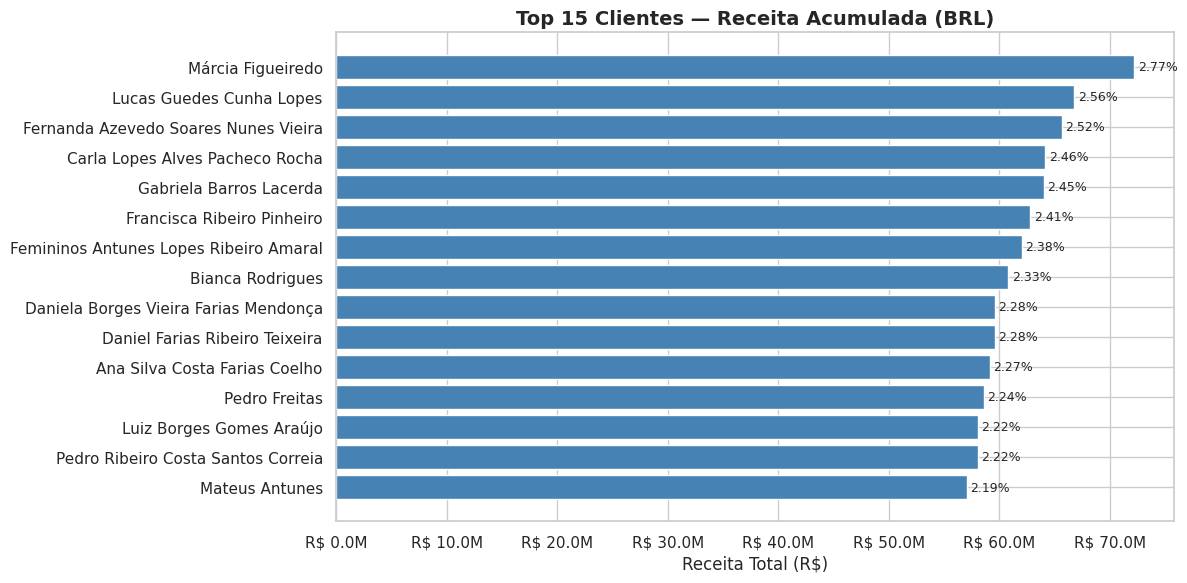

=== TOP 15 CLIENTES — Receita Acumulada ===
                                  nome  receita_total_brl  pct_receita_total
                     Márcia Figueiredo        72187369.50               2.77
              Lucas Guedes Cunha Lopes        66788855.35               2.56
  Fernanda Azevedo Soares Nunes Vieira        65652931.35               2.52
       Carla Lopes Alves Pacheco Rocha        64171776.55               2.46
               Gabriela Barros Lacerda        64003343.75               2.45
            Francisca Ribeiro Pinheiro        62791038.15               2.41
Femininos Antunes Lopes Ribeiro Amaral        62028628.95               2.38
                      Bianca Rodrigues        60826837.25               2.33
 Daniela Borges Vieira Farias Mendonça        59581398.75               2.28
        Daniel Farias Ribeiro Teixeira        59575349.10               2.28
         Ana Silva Costa Farias Coelho        59126834.35               2.27
                         Pedro F

In [0]:
# Visualização: top 15 clientes por receita acumulada
top15 = receita_cliente.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15['nome'], top15['receita_total_brl'], color='steelblue')
ax.set_title('Top 15 Clientes — Receita Acumulada (BRL)', fontsize=14, fontweight='bold')
ax.set_xlabel('Receita Total (R$)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.invert_yaxis()

for bar, pct in zip(bars, top15['pct_receita_total']):
    ax.text(bar.get_width() * 1.005, bar.get_y() + bar.get_height() / 2,
            f'{pct}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()
# --- resumo textual ---
print('=== TOP 15 CLIENTES — Receita Acumulada ===')
print(top15[['nome','receita_total_brl','pct_receita_total']].to_string(index=False))


## 3. Segmentação RFM Simplificada

RFM é uma técnica clássica de segmentação de clientes baseada em três dimensões:
- **R (Recência):** há quantos dias o cliente fez a última compra
- **F (Frequência):** quantas compras realizou no período
- **M (Monetário):** quanto gastou no total

Aqui usamos uma versão simplificada: cada dimensão é classificada em quintis (1 a 5), e os clientes são agrupados em segmentos estratégicos com base na combinação.

In [0]:
# Calcula R, F, M por cliente e classifica em quintis
rfm = spark.sql("""
    WITH base AS (
        SELECT
            id_client,
            -- Recência: dias desde a última compra até o fim do período (2024-12-31)
            DATEDIFF(DATE '2024-12-31', MAX(sale_date)) AS recencia_dias,
            COUNT(*)                                             AS frequencia,
            ROUND(SUM(total), 2)                                 AS monetario
        FROM workspace.lh_nautical.gold_fct_vendas
        GROUP BY id_client
    ),
    quintis AS (
        SELECT
            id_client,
            recencia_dias,
            frequencia,
            monetario,
            -- Recência: menor = mais recente = melhor (quintil invertido)
            NTILE(5) OVER (ORDER BY recencia_dias DESC) AS r_score,
            NTILE(5) OVER (ORDER BY frequencia ASC)     AS f_score,
            NTILE(5) OVER (ORDER BY monetario ASC)      AS m_score
        FROM base
    )
    SELECT
        q.*,
        c.full_name                                     AS nome,
        c.location                                         AS estado,
        (r_score + f_score + m_score)                   AS rfm_score,
        CASE
            WHEN (r_score + f_score + m_score) >= 13 THEN 'Campeão'
            WHEN (r_score + f_score + m_score) >= 10 THEN 'Fiel'
            WHEN (r_score + f_score + m_score) >= 7  THEN 'Potencial'
            WHEN r_score >= 4                         THEN 'Novo'
            ELSE 'Em Risco'
        END                                             AS segmento
    FROM quintis q
    JOIN workspace.lh_nautical.silver_clientes c ON q.id_client = c.id_client
    ORDER BY rfm_score DESC
""").toPandas()

print(rfm[['nome', 'estado', 'recencia_dias', 'frequencia', 'monetario',
             'r_score', 'f_score', 'm_score', 'rfm_score', 'segmento']]
    .to_string(index=False)
)

                                       nome                         estado  recencia_dias  frequencia   monetario  r_score  f_score  m_score  rfm_score  segmento
       Fernanda Azevedo Soares Nunes Vieira                    PE , Recife              0         220 65652931.35        5        5        5         15   Campeão
                 Francisca Ribeiro Pinheiro                       Belém/PA              0         215 62791038.15        5        5        5         15   Campeão
                   Lucas Guedes Cunha Lopes               PB - João Pessoa              1         218 66788855.35        4        5        5         14   Campeão
     Femininos Antunes Lopes Ribeiro Amaral                ES / São Mateus              1         217 62028628.95        4        5        5         14   Campeão
                   Luiz Borges Gomes Araújo                      Manaus/AM              1         213 58073741.00        4        5        4         13   Campeão
                          Má

Distribuição de clientes por segmento RFM:
 segmento  qtd_clientes
Potencial            19
     Fiel            12
 Em Risco            10
  Campeão             7
     Novo             1


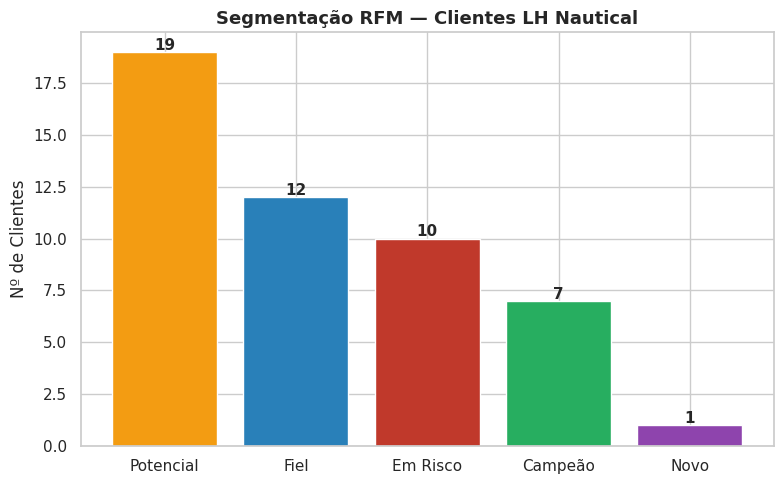

In [0]:
# Distribuição por segmento
segmentos = rfm['segmento'].value_counts().reset_index()
segmentos.columns = ['segmento', 'qtd_clientes']

print('Distribuição de clientes por segmento RFM:')
print(segmentos.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
cores = {'Campeão': '#27ae60', 'Fiel': '#2980b9',
         'Potencial': '#f39c12', 'Novo': '#8e44ad', 'Em Risco': '#c0392b'}
bars = ax.bar(segmentos['segmento'],
              segmentos['qtd_clientes'],
              color=[cores.get(s, 'gray') for s in segmentos['segmento']])
ax.set_title('Segmentação RFM — Clientes LH Nautical', fontsize=13, fontweight='bold')
ax.set_ylabel('Nº de Clientes')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Distribuição Geográfica

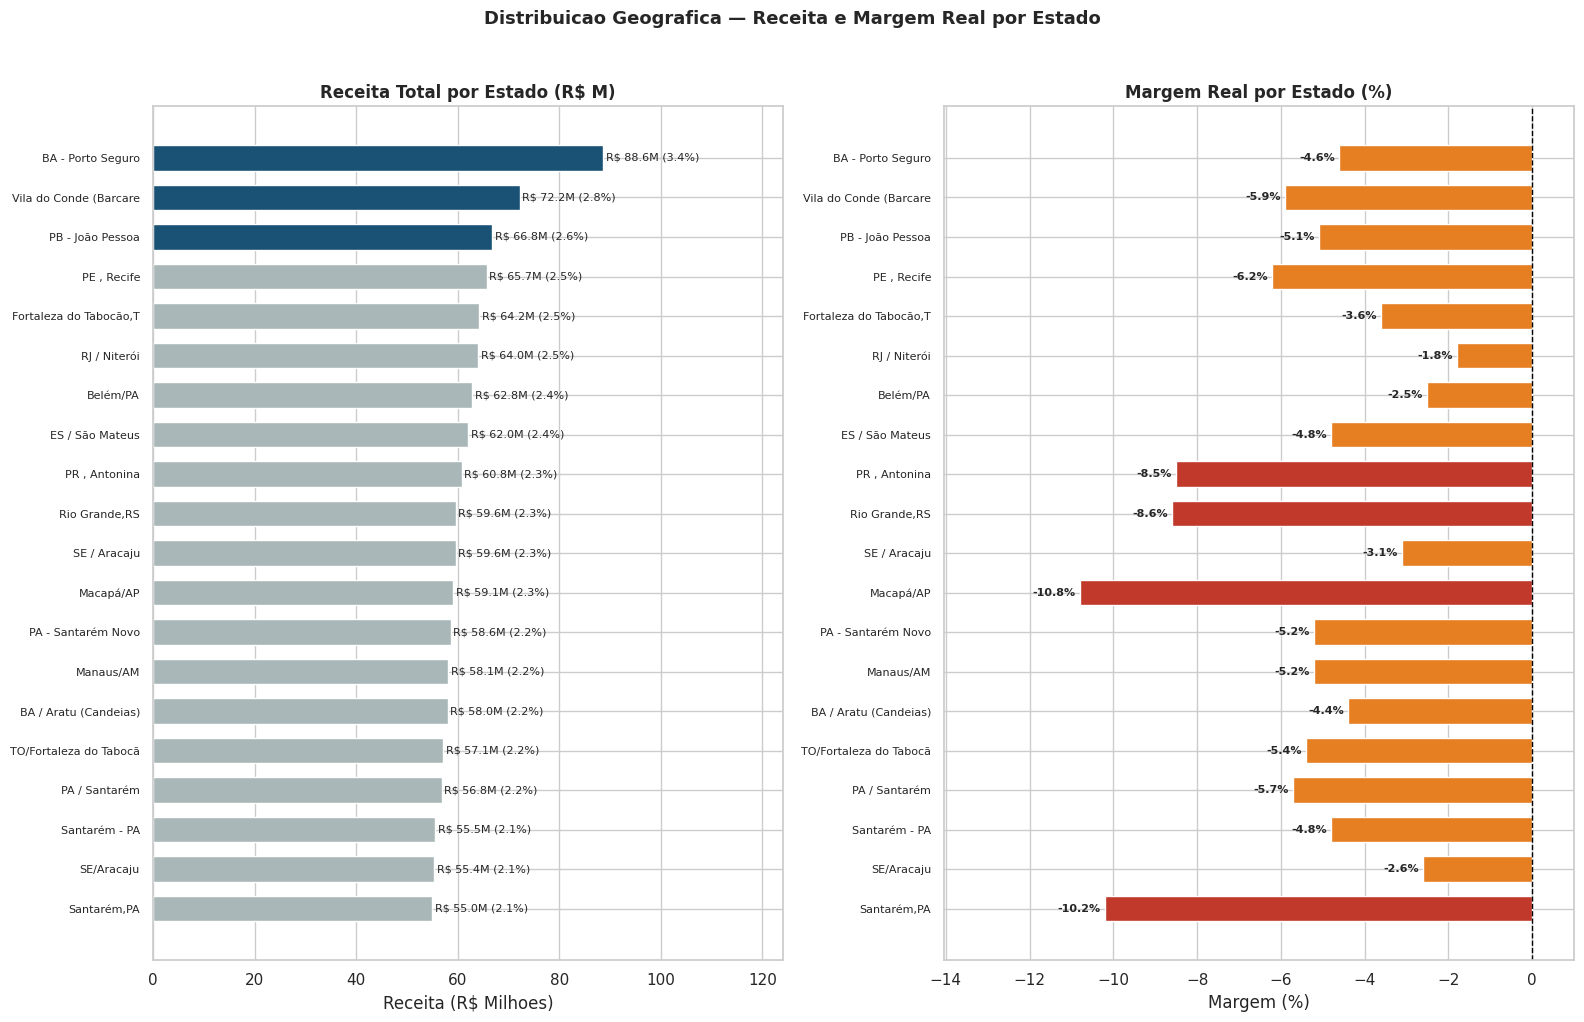

Estados com clientes: 48
Top 3 por receita: ['BA - Porto Seguro', 'Vila do Conde (Barcarena) - PA', 'PB - João Pessoa'] — 8.8% da receita total
Melhor margem: RJ / Niterói (-1.8%)
Pior margem  : Macapá/AP (-10.8%)

Todos os estados com margem negativa — crise e sistemica, nao geografica.
                        estado  clientes  receita_m  pct_receita  margem_pct
             BA - Porto Seguro         2       88.6          3.4        -4.6
Vila do Conde (Barcarena) - PA         1       72.2          2.8        -5.9
              PB - João Pessoa         1       66.8          2.6        -5.1
                   PE , Recife         1       65.7          2.5        -6.2
       Fortaleza do Tabocão,TO         1       64.2          2.5        -3.6
                  RJ / Niterói         1       64.0          2.5        -1.8
                      Belém/PA         1       62.8          2.4        -2.5
               ES / São Mateus         1       62.0          2.4        -4.8
                 P

In [0]:
# Distribuicao geografica — receita e margem real por estado (Lendo Camada Gold)
geo = spark.sql("""
    SELECT
        c.location                                                          AS estado,
        COUNT(DISTINCT c.id_client)                                           AS clientes,
        ROUND(SUM(v.total)/1e6, 1)                                       AS receita_m,
        ROUND(100.0*SUM(v.total)/SUM(SUM(v.total)) OVER(), 1)            AS pct_receita,
        ROUND(SUM(v.lucro)/SUM(v.total)*100, 1)                          AS margem_pct
    FROM workspace.lh_nautical.silver_clientes c
    JOIN workspace.lh_nautical.gold_fct_vendas v ON c.id_client = v.id_client
    GROUP BY c.location
    ORDER BY receita_m DESC
""").toPandas()

# Truncar labels longos e filtrar top 20 por receita
geo_plot = geo.head(20).copy()
geo_plot['label'] = geo_plot['estado'].str[:22]

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Painel 1: Receita por estado
cores_r = ['#1a5276' if i < 3 else '#aab7b8' for i in range(len(geo_plot))]
bars = axes[0].barh(geo_plot['label'], geo_plot['receita_m'], color=cores_r, height=0.65)
axes[0].set_title('Receita Total por Estado (R$ M)', fontweight='bold')
axes[0].set_xlabel('Receita (R$ Milhoes)')
axes[0].invert_yaxis()
axes[0].tick_params(axis='y', labelsize=8)
for bar, row in zip(bars, geo_plot.itertuples()):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'R$ {row.receita_m}M ({row.pct_receita}%)',
                 va='center', fontsize=8)
axes[0].set_xlim(0, geo_plot['receita_m'].max() * 1.4)

# Painel 2: Margem real por estado
cores_m = ['#1e8449' if m >= 0 else '#c0392b' if m < -7 else '#e67e22'
           for m in geo_plot['margem_pct']]
bars2 = axes[1].barh(geo_plot['label'], geo_plot['margem_pct'], color=cores_m, height=0.65)
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_title('Margem Real por Estado (%)', fontweight='bold')
axes[1].set_xlabel('Margem (%)')
axes[1].invert_yaxis()
axes[1].tick_params(axis='y', labelsize=8)
for bar, row in zip(bars2, geo_plot.itertuples()):
    offset = 0.1 if row.margem_pct >= 0 else -0.1
    ha = 'left' if row.margem_pct >= 0 else 'right'
    axes[1].text(row.margem_pct + offset, bar.get_y() + bar.get_height()/2,
                 f'{row.margem_pct}%', va='center', ha=ha, fontsize=8, fontweight='bold')
axes[1].set_xlim(geo_plot['margem_pct'].min() * 1.3, 1)

plt.suptitle('Distribuicao Geografica — Receita e Margem Real por Estado',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../assets/img/distribuicao_geografica.png", dpi=150, bbox_inches="tight")
plt.show()

melhor_estado = geo.loc[geo['margem_pct'].idxmax(), 'estado']
pior_estado   = geo.loc[geo['margem_pct'].idxmin(), 'estado']
print(f'Estados com clientes: {len(geo)}')
print(f'Top 3 por receita: {list(geo.head(3)["estado"])} — {geo.head(3)["pct_receita"].sum():.1f}% da receita total')
print(f'Melhor margem: {melhor_estado} ({geo.loc[geo["margem_pct"].idxmax(), "margem_pct"]}%)')
print(f'Pior margem  : {pior_estado} ({geo.loc[geo["margem_pct"].idxmin(), "margem_pct"]}%)')
print()
print('Todos os estados com margem negativa — crise e sistemica, nao geografica.')
print(geo.to_string(index=False))


In [0]:
# Agregacao por ESTADO (UF) — extrai sigla de 2 letras do campo location
import re as _re

def extrair_uf(loc):
    m = _re.search(r'\b([A-Z]{2})\b', str(loc))
    return m.group(1) if m else 'Outros'

geo_estado = (
    geo
    .assign(uf=lambda d: d['estado'].apply(extrair_uf))
    .groupby('uf')
    .agg(receita_m=('receita_m', 'sum'), clientes=('clientes', 'sum'))
    .reset_index()
    .assign(pct_receita=lambda d: (d['receita_m'] / d['receita_m'].sum() * 100).round(1))
    .sort_values('receita_m', ascending=False)
    .reset_index(drop=True)
)

top3 = geo_estado.head(3)
pct_top3 = top3['pct_receita'].sum()
estados_top3 = ', '.join(top3['uf'].tolist())

print('=== RECEITA POR ESTADO (UF) ===')
print(geo_estado.to_string(index=False))
print(f'\nTop 3 estados: {estados_top3} — {pct_top3:.1f}% da receita total')


=== RECEITA POR ESTADO (UF) ===
uf  receita_m  clientes  pct_receita
PA      457.7         8         17.5
BA      241.5         5          9.3
TO      225.0         4          8.6
SE      167.2         3          6.4
PE      165.0         3          6.3
PB      164.3         3          6.3
AM      154.4         3          5.9
MA      152.2         3          5.8
CE      135.3         3          5.2
PR      113.8         2          4.4
RS      105.9         2          4.1
AC      102.5         2          3.9
MS       90.5         2          3.5
RJ       64.0         1          2.5
ES       62.0         1          2.4
AP       59.1         1          2.3
AL       53.5         1          2.0
SC       51.1         1          2.0
SP       45.3         1          1.7

Top 3 estados: PA, BA, TO — 35.4% da receita total


## 5. Vendas Médias por Dia da Semana

**Atenção:** a média simples ignoraria os dias sem venda, distorcendo o resultado. A abordagem correta é gerar um calendário completo com todos os dias do período, fazer um `LEFT JOIN` com as vendas e tratar os dias sem venda como **zero** antes de calcular a média.

Isso responde a questão 6 do desafio.

In [0]:
# Calendário completo + LEFT JOIN com vendas + média por dia da semana
dia_semana = spark.sql("""
    WITH
    -- Gera todos os dias do período (2023-01-01 a 2024-12-31)
    calendario AS (
        SELECT explode(sequence(to_date('2023-01-01'), to_date('2024-12-31'), interval 1 day)) AS dia
    ),
    -- Receita total por dia de venda
    vendas_dia AS (
        SELECT
            sale_date,
            SUM(total) AS receita_dia
        FROM workspace.lh_nautical.gold_fct_vendas
        GROUP BY sale_date
    ),
    -- Junta calendário com vendas — dias sem venda recebem 0
    calendario_completo AS (
        SELECT
            c.dia,
            COALESCE(v.receita_dia, 0) AS receita
        FROM calendario c
        LEFT JOIN vendas_dia v ON c.dia = v.sale_date
    )
    -- Média por dia da semana com nome em português
    SELECT
        (dayofweek(dia) - 1)                          AS dia_num,
        CASE (dayofweek(dia) - 1)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda'
            WHEN 2 THEN 'Terça'
            WHEN 3 THEN 'Quarta'
            WHEN 4 THEN 'Quinta'
            WHEN 5 THEN 'Sexta'
            WHEN 6 THEN 'Sábado'
        END                                     AS dia_semana,
        COUNT(*)                                AS total_dias,
        SUM(CASE WHEN receita > 0 THEN 1 ELSE 0 END) AS dias_com_venda,
        ROUND(AVG(receita), 2)                  AS receita_media_brl
    FROM calendario_completo
    GROUP BY dia_num, dia_semana
    ORDER BY dia_num
""").toPandas()

print(dia_semana.to_string(index=False))

 dia_num dia_semana  total_dias  dias_com_venda  receita_media_brl
       0    Domingo         105             103         3319503.57
       1    Segunda         105             103         3465137.71
       2      Terça         105             103         3627045.76
       3     Quarta         104             104         3535265.63
       4     Quinta         104             104         3626232.44
       5      Sexta         104             104         3715003.41
       6     Sábado         104             104         3710540.55


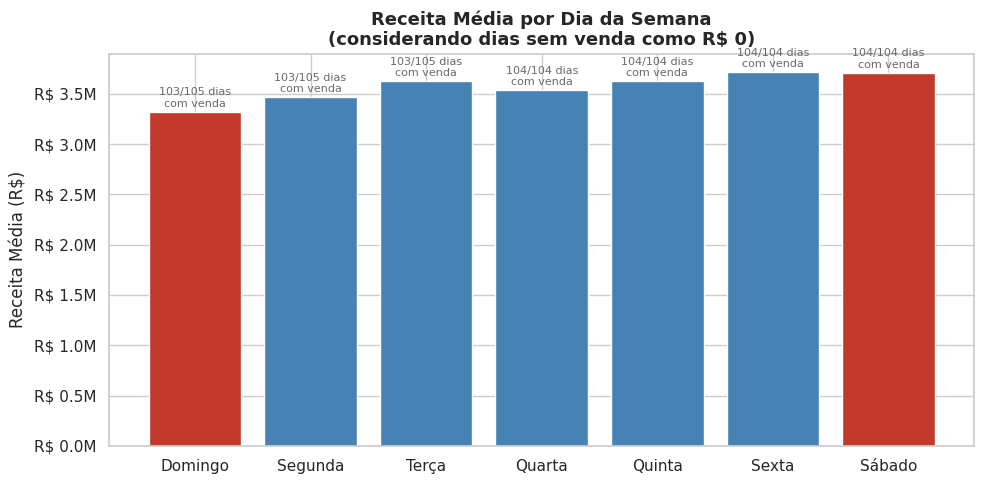

=== RECEITA MÉDIA POR DIA DA SEMANA ===
dia_semana  receita_media_brl  dias_com_venda  total_dias
   Domingo         3319503.57             103         105
   Segunda         3465137.71             103         105
     Terça         3627045.76             103         105
    Quarta         3535265.63             104         104
    Quinta         3626232.44             104         104
     Sexta         3715003.41             104         104
    Sábado         3710540.55             104         104


In [0]:
# Visualização: receita média por dia da semana (com zeros incluídos)
fig, ax = plt.subplots(figsize=(10, 5))

# Comparação por substring — robusto a variações de encoding
cores = ['#c0392b' if n in [0, 6] else 'steelblue'
         for n in dia_semana['dia_num']]

bars = ax.bar(dia_semana['dia_semana'], dia_semana['receita_media_brl'], color=cores)
ax.set_title('Receita Média por Dia da Semana\n(considerando dias sem venda como R$ 0)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Receita Média (R$)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))

for bar, row in zip(bars, dia_semana.itertuples()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50000,
            f'{row.dias_com_venda}/{row.total_dias} dias\ncom venda',
            ha='center', fontsize=8, color='dimgray')

plt.tight_layout()
plt.savefig("../assets/img/vendas_dia_semana.png", dpi=150, bbox_inches="tight")
plt.show()
# --- resumo textual ---
print('=== RECEITA MÉDIA POR DIA DA SEMANA ===')
print(dia_semana[['dia_semana','receita_media_brl','dias_com_venda','total_dias']].to_string(index=False))


In [0]:
# Robustez da Questao 6: compara media DIARIA com zeros vs media DIARIA apenas em dias com venda
# Nota: a query abaixo agrega por dia primeiro (SUM(total) por sale_date) e depois calcula
# AVG por dia da semana — mesma unidade que o metodo com zeros, permitindo comparacao direta.
dia_semana_sem_zeros = spark.sql("""
    WITH vendas_dia AS (
        SELECT
            sale_date,
            SUM(total) AS receita_dia
        FROM workspace.lh_nautical.gold_fct_vendas
        GROUP BY sale_date
    )
    SELECT
        (dayofweek(sale_date) - 1)              AS dia_num,
        CASE (dayofweek(sale_date) - 1)
            WHEN 0 THEN 'Domingo'
            WHEN 1 THEN 'Segunda'
            WHEN 2 THEN 'Terca'
            WHEN 3 THEN 'Quarta'
            WHEN 4 THEN 'Quinta'
            WHEN 5 THEN 'Sexta'
            WHEN 6 THEN 'Sabado'
        END                               AS dia_semana,
        COUNT(*)                          AS dias_com_venda,
        ROUND(AVG(receita_dia), 2)        AS receita_media_sem_zeros
    FROM vendas_dia
    GROUP BY dia_num, dia_semana
    ORDER BY dia_num
""").toPandas()

comp_q6 = (
    dia_semana[['dia_num', 'dia_semana', 'receita_media_brl']]
    .rename(columns={'receita_media_brl': 'media_com_zeros'})
    .merge(
        dia_semana_sem_zeros[['dia_num', 'receita_media_sem_zeros']],
        on='dia_num',
        how='left'
    )
    .rename(columns={'receita_media_sem_zeros': 'media_sem_zeros'})
    .assign(
        diferenca_pct=lambda d: ((d['media_sem_zeros'] / d['media_com_zeros']) - 1) * 100
    )
    .round({'media_com_zeros': 2, 'media_sem_zeros': 2, 'diferenca_pct': 1})
    .sort_values('dia_num')
    .reset_index(drop=True)
)

melhor_com_zeros = comp_q6.loc[comp_q6['media_com_zeros'].idxmax(), 'dia_semana']
melhor_sem_zeros = comp_q6.loc[comp_q6['media_sem_zeros'].idxmax(), 'dia_semana']

print('=== ROBUSTEZ METODOLOGICA - QUESTAO 6 ===')
print(f"Melhor dia com zeros (metodo oficial): {melhor_com_zeros}")
print(f"Melhor dia sem zeros (media diaria)  : {melhor_sem_zeros}")
print('Nota: diferenca < 2% pois quase todos os dias do periodo possuem vendas.')
print(comp_q6[['dia_semana', 'media_com_zeros', 'media_sem_zeros', 'diferenca_pct']].to_string(index=False))

=== ROBUSTEZ METODOLOGICA - QUESTAO 6 ===
Melhor dia com zeros (metodo oficial): Sexta
Melhor dia sem zeros (media diaria)  : Sexta
Nota: diferenca < 2% pois quase todos os dias do periodo possuem vendas.
dia_semana  media_com_zeros  media_sem_zeros  diferenca_pct
   Domingo       3319503.57       3383959.95            1.9
   Segunda       3465137.71       3532421.94            1.9
     Terça       3627045.76       3697473.84            1.9
    Quarta       3535265.63       3535265.63            0.0
    Quinta       3626232.44       3626232.44            0.0
     Sexta       3715003.41       3715003.41            0.0
    Sábado       3710540.55       3710540.55            0.0


## 6. Rentabilidade por Cliente

Com o câmbio real da API PTAX/BCB (silver_cambio (Delta Lake)), calculamos custo e lucro por transação e agregamos por cliente.

**Pergunta central:** o cliente que mais gera receita é o que mais gera lucro?

In [0]:
# Rentabilidade por cliente consumindo a Camada Ouro (vendas_gold.csv)
lucro_cliente = spark.sql("""
    SELECT
        v.id_client,
        c.full_name AS nome,
        c.location AS estado,
        COUNT(*) AS qtd_trans,
        ROUND(SUM(v.total), 2) AS receita_total,
        ROUND(SUM(v.custo_brl), 2) AS custo_total,
        ROUND(SUM(v.lucro), 2) AS lucro_total,
        ROUND(SUM(v.lucro) / SUM(v.total) * 100, 1) AS margem_pct
    FROM workspace.lh_nautical.gold_fct_vendas v
    JOIN workspace.lh_nautical.silver_clientes c ON v.id_client = c.id_client
    GROUP BY v.id_client, c.full_name, c.location
    ORDER BY lucro_total DESC
""").toPandas()

n_pos = (lucro_cliente['lucro_total'] >= 0).sum()
n_neg = (lucro_cliente['lucro_total'] <  0).sum()
margem_carteira = lucro_cliente['lucro_total'].sum() / lucro_cliente['receita_total'].sum() * 100

print(f'Clientes com lucro positivo : {n_pos}')
print(f'Clientes com prejuizo       : {n_neg}')
print(f'Margem media da carteira    : {margem_carteira:.1f}%')

# Rank receita vs rank margem
# method='min': empates recebem o menor rank inteiro (evita floats do method='average')
lucro_cliente['rank_receita'] = lucro_cliente['receita_total'].rank(ascending=False, method='min').astype(int)
lucro_cliente['rank_margem']  = lucro_cliente['margem_pct'].rank(ascending=False, method='min').astype(int)
lucro_cliente['delta_rank']   = lucro_cliente['rank_receita'] - lucro_cliente['rank_margem']

print(lucro_cliente[['nome','estado','receita_total','custo_total','lucro_total',
                        'margem_pct','rank_receita','rank_margem','delta_rank']]
    .to_string(index=False)
)

Clientes com lucro positivo : 0
Clientes com prejuizo       : 49
Margem media da carteira    : -5.3%
                                       nome                         estado  receita_total  custo_total  lucro_total  margem_pct  rank_receita  rank_margem  delta_rank
                    Gabriela Barros Lacerda                   RJ / Niterói    64003343.75  65157752.22  -1154408.47        -1.8             5            1           4
      Victor Araújo Azevedo Tavares Correia               Itacoatiara - AM    41818885.75  43005884.94  -1186999.19        -2.8            46            4          42
                   Bruna Mendonça Rodrigues                    Santos - SP    45279072.85  46592869.63  -1313796.78        -2.9            42            5          37
                Diego Costa Tavares Antunes                     SE/Aracaju    55358316.80  56773645.06  -1415328.26        -2.6            18            3          15
                 Francisca Ribeiro Pinheiro                     

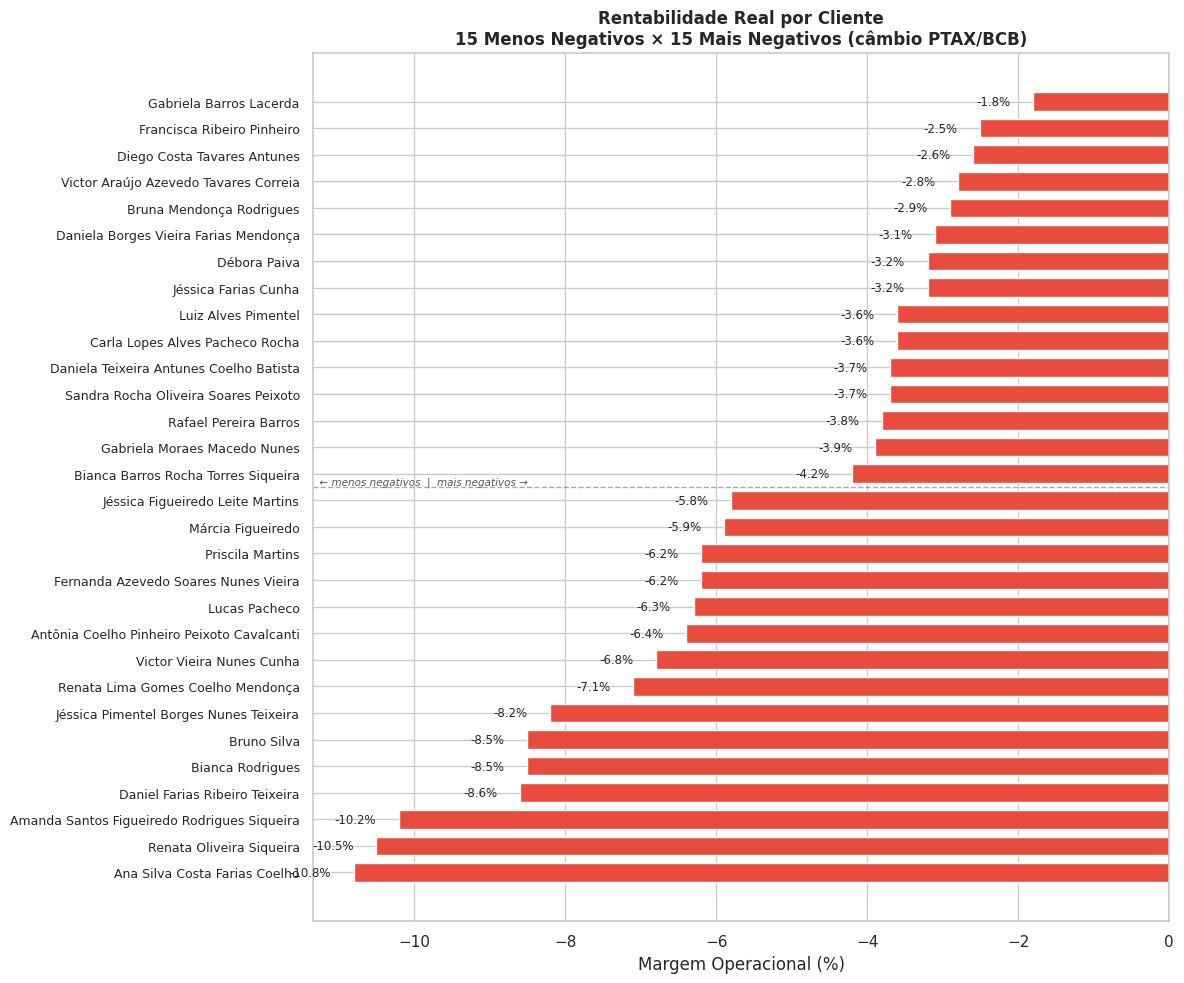


=== MAIORES DIVERGENCIAS: RANK RECEITA vs RANK MARGEM ===
(delta positivo = cliente parece melhor na receita do que na margem real)
                                       nome  receita_total  lucro_total  margem_pct  rank_receita  rank_margem  delta_rank
      Victor Araújo Azevedo Tavares Correia    41818885.75  -1186999.19        -2.8            46            4          42
              Ana Silva Costa Farias Coelho    59126834.35  -6382413.95       -10.8            11           49         -38
                   Bruna Mendonça Rodrigues    45279072.85  -1313796.78        -2.9            42            5          37
             Daniel Farias Ribeiro Teixeira    59575349.10  -5141355.03        -8.6            10           46         -36
                           Bianca Rodrigues    60826837.25  -5155110.08        -8.5             8           44         -36
                          Márcia Figueiredo    72187369.50  -4280857.79        -5.9             1           36         -35
      

In [0]:
# Top 15 melhores + Bottom 15 piores por margem
top15_cli = lucro_cliente.nlargest(15, 'margem_pct')
bot15_cli = lucro_cliente.nsmallest(15, 'margem_pct')
ranking_df = pd.concat([top15_cli, bot15_cli]).drop_duplicates().sort_values('margem_pct').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 10))
cores_bar = ['#2ecc71' if m >= 0 else '#e74c3c' for m in ranking_df['margem_pct']]
bars = ax.barh(ranking_df['nome'], ranking_df['margem_pct'], color=cores_bar, height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Rentabilidade Real por Cliente\n15 Menos Negativos × 15 Mais Negativos (câmbio PTAX/BCB)', fontweight='bold')
ax.set_xlabel('Margem Operacional (%)')
ax.tick_params(axis='y', labelsize=9)
for bar, row in zip(bars, ranking_df.itertuples()):
    offset = 0.3 if row.margem_pct >= 0 else -0.3
    ha = 'left' if row.margem_pct >= 0 else 'right'
    ax.text(row.margem_pct + offset, bar.get_y() + bar.get_height()/2,
            f'{row.margem_pct:.1f}%', va='center', ha=ha, fontsize=8.5)
# Linha separando os dois grupos
ax.axhline(14.5, color='#555', linewidth=1, linestyle='--', alpha=0.5)
ax.text(ax.get_xlim()[0], 14.5, '  ← menos negativos  |  mais negativos →  ',
        va='bottom', fontsize=7.5, color='#555', style='italic')
plt.tight_layout()
plt.savefig('../assets/img/ranking_clientes.png', dpi=150, bbox_inches='tight')
plt.show()

# Maiores divergências entre rank de receita e rank de margem
print('\n=== MAIORES DIVERGENCIAS: RANK RECEITA vs RANK MARGEM ===')
print('(delta positivo = cliente parece melhor na receita do que na margem real)')
print(
    lucro_cliente
    .sort_values('delta_rank', key=abs, ascending=False)
    .head(10)
    [['nome','receita_total','lucro_total','margem_pct','rank_receita','rank_margem','delta_rank']]
    .to_string(index=False)
)

=== QUESTAO 5 — RANKING DE LUCRO ACUMULADO POR CLIENTE ===
 posicao                                    nome                    estado  receita_total  lucro_total  margem_pct status_lucro
       1                 Gabriela Barros Lacerda              RJ / Niterói    64003343.75  -1154408.47        -1.8     Prejuizo
       2   Victor Araújo Azevedo Tavares Correia          Itacoatiara - AM    41818885.75  -1186999.19        -2.8     Prejuizo
       3                Bruna Mendonça Rodrigues               Santos - SP    45279072.85  -1313796.78        -2.9     Prejuizo
       4             Diego Costa Tavares Antunes                SE/Aracaju    55358316.80  -1415328.26        -2.6     Prejuizo
       5              Francisca Ribeiro Pinheiro                  Belém/PA    62791038.15  -1586494.97        -2.5     Prejuizo
       6                            Débora Paiva             Santarém / PA    51674436.80  -1670881.26        -3.2     Prejuizo
       7                    Jéssica Farias Cu

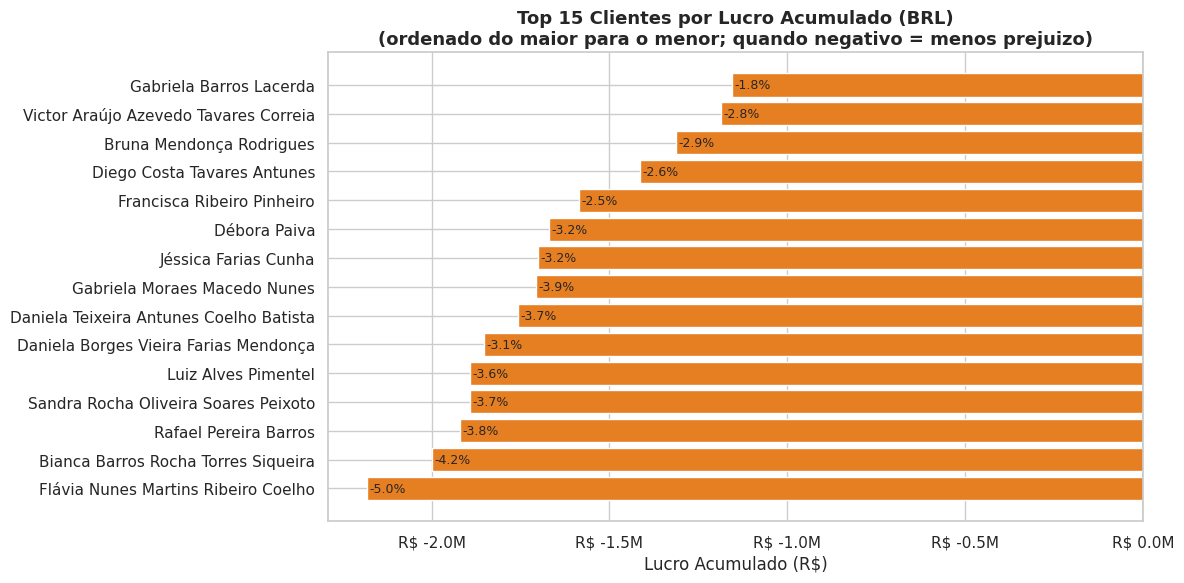

Leitura correta do grafico para este caso: como todos estao no vermelho, o topo representa os clientes com menor prejuizo acumulado.


In [0]:
# Questao 5 (aderencia literal): ranking de lucro acumulado por cliente
print('=== QUESTAO 5 — RANKING DE LUCRO ACUMULADO POR CLIENTE ===')

ranking_lucro = (
    lucro_cliente[['id_client', 'nome', 'estado', 'receita_total', 'lucro_total', 'margem_pct']]
    .copy()
    .sort_values('lucro_total', ascending=False)
    .reset_index(drop=True)
    .assign(
        posicao=lambda d: d.index + 1,
        status_lucro=lambda d: d['lucro_total'].apply(lambda x: 'Lucro' if x >= 0 else 'Prejuizo')
)
 )

# Top 15 por lucro acumulado (na pratica, os menos negativos primeiro)
top15_lucro = ranking_lucro.head(15).copy()
print(
    top15_lucro[['posicao', 'nome', 'estado', 'receita_total', 'lucro_total', 'margem_pct', 'status_lucro']]
    .to_string(index=False)
)

fig, ax = plt.subplots(figsize=(12, 6))
cores = ['#2ecc71' if v >= 0 else '#e67e22' for v in top15_lucro['lucro_total']]
bars = ax.barh(top15_lucro['nome'], top15_lucro['lucro_total'], color=cores)

ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Top 15 Clientes por Lucro Acumulado (BRL)\n(ordenado do maior para o menor; quando negativo = menos prejuizo)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Lucro Acumulado (R$)')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))

for bar, margem in zip(bars, top15_lucro['margem_pct']):
    ax.text(
        bar.get_width() + (0.003 * max(top15_lucro['lucro_total'].abs().max(), 1)),
        bar.get_y() + bar.get_height() / 2,
        f'{margem:.1f}%',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

print('Leitura correta do grafico para este caso: como todos estao no vermelho, o topo representa os clientes com menor prejuizo acumulado.')

## 7. RFM × Margem — Lealdade vs Rentabilidade Real

Cruzamento dos segmentos RFM com a margem operacional real.

Pergunta central: **os clientes mais leais são também os menos prejudiciais à margem?**

=== SEGMENTO RFM × MARGEM OPERACIONAL REAL ===
 segmento  Clientes  Margem Média (%)  Receita Total (R$)  Lucro Total (R$ M)
     Novo         1              -2.8          41818885.8               -1.19
  Campeão         7              -4.8         451694340.8              -21.68
     Fiel        12              -4.8         644087958.4              -31.44
Potencial        19              -5.4        1027759896.2              -56.31
 Em Risco        10              -6.3         444918429.5              -28.22


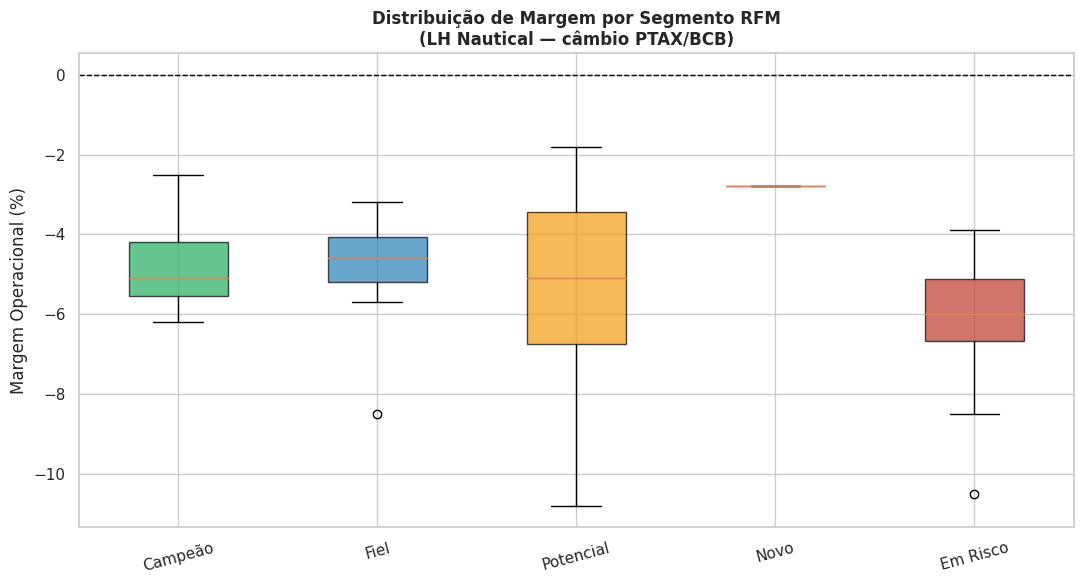


=== CLIENTES EM RISCO (RFM) — ordenados por margem mais negativa ===
                               nome  rfm_score  recencia_dias  frequencia  receita_total  lucro_total  margem_pct
           Renata Oliveira Siqueira          3              6         188    45644652.90  -4774885.11       -10.5
                        Bruno Silva          6              1         196    45135761.20  -3835998.89        -8.5
          Victor Vieira Nunes Cunha          5              1         185    39126528.90  -2659783.23        -6.8
                      Lucas Pacheco          5              1         180    40453858.75  -2542445.37        -6.3
                   Priscila Martins          5              3         190    49976734.45  -3096523.99        -6.2
   Jéssica Figueiredo Leite Martins          3              9         172    45527113.80  -2653481.08        -5.8
             Victor Torres Monteiro          3              6         176    41516820.00  -2302452.28        -5.5
Flávia Nunes Marti

In [0]:
# Junta RFM com margem real por cliente
rfm_margem = (
    rfm[['id_client', 'segmento', 'rfm_score']]
    .merge(
        lucro_cliente[['id_client', 'receita_total', 'lucro_total', 'margem_pct']],
        on='id_client'
    )
)

# Resumo por segmento RFM
resumo_rfm = (
    rfm_margem
    .groupby('segmento')
    .agg(
        n_clientes   =('id_client',    'count'),
        margem_media =('margem_pct',   'mean'),
        lucro_total  =('lucro_total',  'sum'),
        receita_total=('receita_total','sum')
    )
    .round(1)
    .assign(lucro_total_M=lambda d: (d['lucro_total']/1e6).round(2))
    .drop(columns='lucro_total')
    .rename(columns={
        'n_clientes'   : 'Clientes',
        'margem_media' : 'Margem Média (%)',
        'lucro_total_M': 'Lucro Total (R$ M)',
        'receita_total': 'Receita Total (R$)'
    })
    # Ordena por margem (menos negativa primeiro)
    .sort_values('Margem Média (%)', ascending=False)
    .reset_index()
)

print('=== SEGMENTO RFM × MARGEM OPERACIONAL REAL ===')
print(resumo_rfm.to_string(index=False))

# Scatter: rfm_score vs margem_pct com cor por segmento
CORES_SEG = {
    'Campeão'  : '#27ae60',
    'Fiel'     : '#2980b9',
    'Potencial': '#f39c12',
    'Novo'     : '#8e44ad',
    'Em Risco' : '#c0392b',
}

# Box plot: distribuição de margem por segmento RFM (full-width)
fig, ax = plt.subplots(figsize=(11, 6))
ordem = ['Campeão', 'Fiel', 'Potencial', 'Novo', 'Em Risco']
dados_box = [rfm_margem[rfm_margem['segmento'] == s]['margem_pct'].values for s in ordem]
bp = ax.boxplot(dados_box, labels=ordem, patch_artist=True, widths=0.5)
for patch, seg in zip(bp['boxes'], ordem):
    patch.set_facecolor(CORES_SEG[seg])
    patch.set_alpha(0.7)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Distribuição de Margem por Segmento RFM\n(LH Nautical — câmbio PTAX/BCB)', fontweight='bold')
ax.set_ylabel('Margem Operacional (%)')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig('../assets/img/rfm_margem.png', dpi=150, bbox_inches='tight')
plt.show()

# Clientes Em Risco + pior margem = ação urgente
print('\n=== CLIENTES EM RISCO (RFM) — ordenados por margem mais negativa ===')
print(
    rfm_margem[rfm_margem['segmento'] == 'Em Risco']
    .merge(rfm[['id_client', 'nome', 'recencia_dias', 'frequencia']], on='id_client')
    .sort_values('margem_pct')
    [['nome', 'rfm_score', 'recencia_dias', 'frequencia', 'receita_total', 'lucro_total', 'margem_pct']]
    .reset_index(drop=True)
    .to_string(index=False)
)

## 8. Resumo Executivo

### Para o Gabriel (Tech Lead)
A análise utilizou Spark SQL em todas as etapas. O ponto técnico mais relevante foi a questão 6: em vez de calcular a média direta sobre os dias com venda, geramos um calendário completo com `sequence()` cobrindo 731 dias e aplicamos `LEFT JOIN` — dias sem venda entram como R$ 0 antes do `AVG`. A segmentação RFM foi implementada via `NTILE(5)` em window functions. A rentabilidade por cliente reutiliza a mesma CTE de vigência temporal de custo da Etapa 3, agora agregada por `id_client`. O cruzamento RFM × margem é feito em Python puro com `merge` pós-query.

### Para a Marina (Gerente de Negócios)
| Métrica | Valor |
|---|---|
| Clientes ativos | 49 de 49 cadastrados (100%) |
| Receita média por cliente | R$ 53,3M |
| Ticket médio por transação | R$ 263.797 |
| Cliente com maior receita | Márcia Figueiredo (PA) — R$ 72,2M |
| Concentração top 10 | 24,4% da receita — base distribuída |
| Estado com maior receita | PA — múltiplos clientes, maior volume |
| **Melhor dia da semana** | **Sexta-feira — R$ 3,72M de média (com zeros)** |

**Destaques com câmbio real:**
- **0 de 49 clientes têm lucro positivo** — 100% da carteira opera no vermelho com câmbio real
- Margem média da carteira: **-5,3%** — alinhado com o resultado operacional da Etapa 3
- Márcia Figueiredo lidera em receita (R$ 72,2M) mas ocupa a **posição 36/49 em margem** (-5,9%) — maior receita não significa menor prejuízo
- Clientes **Campeões** têm a margem menos negativa (-4,8%) — prioridade para retenção e reajuste negociado
- **10 clientes Em Risco** no RFM e margem média de -6,3% — dobro de urgência: risco de churn E maior prejuízo por venda

### Para o Sr. Almir (Fundador)
Todos os 49 clientes compraram no período — nenhum ficou parado. Cada cliente gastou em média R$ 53 milhões em dois anos. Porém, com o câmbio real de 2024, **nenhum cliente gerou lucro** — todos os 49 estão vendendo abaixo do custo de importação. O problema não é a frequência de compras, não é a base de clientes, não é a localização. O problema único é que o preço de venda não acompanhou a alta do dólar. Corrigir o preço é a única alavanca que resolve tudo.

In [0]:
def run_all_quality_checks_clientes(resumo_df, receita_cliente_df, lucro_cliente_df, rfm_df, rfm_margem_df):
    """Checks críticos de consistência para a Etapa 4."""
    checks = {
        'resumo_estrutura_ok': set(['total_clientes_cadastrados', 'clientes_com_compra', 'clientes_sem_compra']).issubset(resumo_df.columns),
        'receita_cliente_sem_nulos': receita_cliente_df['receita_total_brl'].isna().sum() == 0,
        'lucro_cliente_sem_nulos': lucro_cliente_df['lucro_total'].isna().sum() == 0,
        'rfm_sem_nulos_criticos': rfm_df[['id_client', 'rfm_score', 'segmento']].isna().sum().sum() == 0,
        'rfm_margem_sem_nulos': rfm_margem_df[['id_client', 'margem_pct']].isna().sum().sum() == 0,
        'todos_clientes_no_vermelho': (lucro_cliente_df['lucro_total'] < 0).all(),
    }
    qa = pd.DataFrame({'check': checks.keys(), 'status': checks.values()})
    qa['resultado'] = qa['status'].map({True: 'PASS', False: 'FAIL'})
    return qa

qa_clientes = run_all_quality_checks_clientes(resumo, receita_cliente, lucro_cliente, rfm, rfm_margem)
print(qa_clientes[['check', 'resultado']].to_string(index=False))

if qa_clientes['status'].all():
    print('RUN_ALL CHECKS (ETAPA 4): PASS')
else:
    print('RUN_ALL CHECKS (ETAPA 4): FAIL')

                     check resultado
       resumo_estrutura_ok      PASS
 receita_cliente_sem_nulos      PASS
   lucro_cliente_sem_nulos      PASS
    rfm_sem_nulos_criticos      PASS
      rfm_margem_sem_nulos      PASS
todos_clientes_no_vermelho      PASS
RUN_ALL CHECKS (ETAPA 4): PASS
